# Baseline — Random Forest

Dataset: IBM Telco Customer Churn (~7.000 registros, 20 features, target `Churn`)

**Fluxo:**
1. Carregar e inspecionar
2. Limpeza
3. Separar features por tipo (numéricas, binárias, categóricas)
4. Separar dataset de treino e de teste
5. Pipeline sklearn (preprocessor + modelo)
6. Treinar e avaliar (accuracy, precision, recall, f1, roc_auc)
7. Matriz de confusão
8. Registrar modelo no MLflow

## 1. Setup

In [1]:
from pathlib import Path

import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

RANDOM_SEED = 42
TARGET = "Churn"
N_SPLITS = 5
PROJECT_ROOT = Path.cwd().parent

## 2. Carregar e limpar

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(DATA_PATH)
print(f"Shape original: {df.shape}")
print(f"Colunas: {list(df.columns)}")
df.head()

Shape original: (7043, 21)
Colunas: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df[TARGET] = df[TARGET].map({"Yes": 1, "No": 0})
df = df.drop(columns=["customerID"])

print(f"Shape após limpeza: {df.shape}")
print(f"\nDistribuição do target:\n{df[TARGET].value_counts(normalize=True)}")

Shape após limpeza: (7043, 20)

Distribuição do target:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


## 3. Definir colunas por tipo

In [4]:
NUM_COLS = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]

BIN_COLS = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
BIN_CATEGORIES = [
    ["Female", "Male"],
    ["No", "Yes"],
    ["No", "Yes"],
    ["No", "Yes"],
    ["No", "Yes"],
]

CAT_COLS = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod",
]

## 4. Validação cruzada (StratifiedKFold k=5)

In [5]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)
print(f"Dataset: {X.shape[0]} amostras | Validação cruzada: {N_SPLITS} folds")

Treino: 5634 amostras | Teste: 1409 amostras
Proporção churn treino: 0.265
Proporção churn teste:  0.265


## 5. Pipeline

In [6]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, NUM_COLS),
        ("bin", OrdinalEncoder(categories=BIN_CATEGORIES), BIN_COLS),
        ("cat", OneHotEncoder(drop="if_binary", sparse_output=False, handle_unknown="ignore"), CAT_COLS),
    ],
    remainder="drop",
)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=RANDOM_SEED,
    )),
])

pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

## 6. Treinar e avaliar

In [7]:
fold_metrics = {k: [] for k in ["accuracy", "roc_auc", "recall", "precision", "f1"]}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    m = clone(pipe)
    m.fit(X_tr, y_tr)

    y_pred = m.predict(X_val)
    y_prob = m.predict_proba(X_val)[:, 1]

    fold_metrics["accuracy"].append(accuracy_score(y_val, y_pred))
    fold_metrics["roc_auc"].append(roc_auc_score(y_val, y_prob))
    fold_metrics["recall"].append(recall_score(y_val, y_pred, zero_division=0))
    fold_metrics["precision"].append(precision_score(y_val, y_pred, zero_division=0))
    fold_metrics["f1"].append(f1_score(y_val, y_pred, zero_division=0))

    print(f"Fold {fold+1}: accuracy={fold_metrics['accuracy'][-1]:.4f}  roc_auc={fold_metrics['roc_auc'][-1]:.4f}  recall={fold_metrics['recall'][-1]:.4f}")

means = {k: float(np.mean(v)) for k, v in fold_metrics.items()}
stds = {k: float(np.std(v)) for k, v in fold_metrics.items()}

print(f"\nResultados (média ± std):")
for metric in ["accuracy", "roc_auc", "recall", "precision", "f1"]:
    print(f"  {metric:12s}: {means[metric]:.4f} ± {stds[metric]:.4f}")

Accuracy:  0.7771
ROC AUC:   0.8171

              precision    recall  f1-score   support

    No Churn       0.82      0.89      0.85      1035
       Churn       0.60      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.76      0.78      0.77      1409



## 7. Matriz de confusão

Recall (sensibilidade):  0.4652
Precision:               0.6042


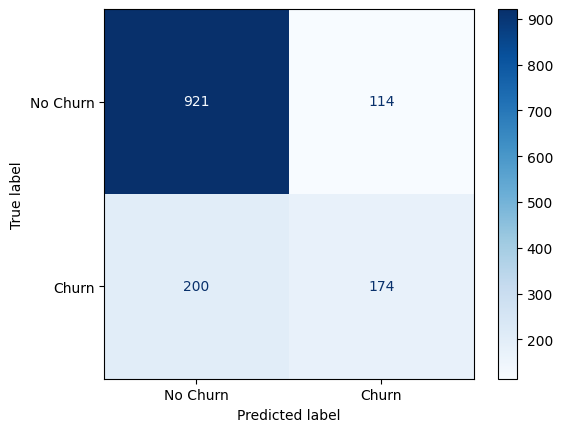

In [8]:
final_model = clone(pipe).fit(X, y)
y_pred_final = final_model.predict(X)
cm = confusion_matrix(y, y_pred_final)
ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(cmap="Blues")
print("Matriz de confusão do modelo final (treinado no dataset completo)")

## 8. Registrar no MLflow

In [9]:
mlflow.set_tracking_uri(f"sqlite:///{PROJECT_ROOT / 'mlflow.db'}")
mlflow.set_experiment("churn-baselines")

with mlflow.start_run(run_name="random_forest"):
    mlflow.log_params({
        "model": "RandomForestClassifier",
        "n_estimators": 100,
        "class_weight": "balanced",
        "random_seed": RANDOM_SEED,
        "cv_folds": N_SPLITS,
    })
    mlflow.log_metrics(means)
    mlflow.log_metrics({f"{k}_std": v for k, v in stds.items()})
    mlflow.sklearn.log_model(final_model, "model")
    run_id = mlflow.active_run().info.run_id

print(f"Run MLflow registrado: {run_id}")
print(f"Métricas (CV média): {means}")

2026/04/22 21:47:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/22 21:47:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/22 21:47:53 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Run MLflow registrado: 1745369c2d654b6c87236ac03ec93816
Métricas: {'accuracy': 0.7771469127040455, 'roc_auc': 0.8171484667648351, 'recall': np.float64(0.46524064171123), 'precision': np.float64(0.6041666666666666)}
